## Swapnil Srivastava -12510029

#### Step1 Import all the required Libraries

In [68]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [69]:
np.set_printoptions(precision=4)  

#### Step2 Read data from the csv

### Tmnst data set is a collection of 26 hand written English alphabets with pixels projected on 784=Dimension ie 28*28 
##### total rows:74724
##### total columns=784



In [70]:
#read data from csv file
df=pd.read_csv('tmnst DATA SET.csv')
df.describe()

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
count,74724.0,74724.0,74724.0,74724.0,74724.0,74724.0,74724.0,74724.0,74724.000000,74724.000000,...,74724.000000,74724.000000,74724.000000,74724.0,74724.0,74724.0,74724.0,74724.0,74724.0,74724.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003667,0.001512,...,0.001405,0.000094,0.000174,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.910918,0.258698,...,0.376832,0.022252,0.047557,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,248.000000,53.000000,...,103.000000,6.000000,13.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Check for nulls

In [71]:
df.isna().sum()

labels    0
1         0
2         0
3         0
4         0
         ..
780       0
781       0
782       0
783       0
784       0
Length: 785, dtype: int64

#### Step3 Normalize each pixel value from [0,1] range instead of [0,255] 

In [72]:
# Identify pixel columns (all columns except 'labels')
pixel_columns = df.columns.drop('labels')

# Normalize pixel values to [0, 1] range
df[pixel_columns] = df[pixel_columns] / 255.0

# Display the head of the DataFrame to show normalized values
display(df.head())

,labels,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,J,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Step 4 Create Train-Test split each class into 70% train and 30% test split 
(no need to encode as data already numerical )

In [73]:
#create 70-30 train-test split
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['labels'])
print(f"Shape of X_train: {train_df.shape}")
print(f"Shape of X_test: {test_df.shape}")


Shape of X_train: (52306, 785)
Shape of X_test: (22418, 785)


# Problem 1

### Visualizing PCA vs. Fisher Scatter Plots

#### The objective is to compare two dimensionality reduction techniques—Principal Component Analysis (PCA) and Fisher’s Linear Discriminant Analysis (LDA)—on a dataset containing four specific classes.
#### Goal: Visualize how 4 different classes cluster in a 3D space.
---
##### Method 1 (Unsupervised): PCA seeks to maximize the variance of the data without knowing the class labels.
##### Method 2 (Supervised): Fisher's LDA seeks to maximize the separation between classes while minimizing the variance within classes. 
---
Since there are $N=4$ classes, the maximum number of discriminant components is $N-1 = 3$.
##### Visualization: The output requires two 3D scatter plots using a specific color scheme (Red, Green, Blue, Cyan) to evaluate which method provides better class separability.

Import libraries for PCA and Linear Discriminant Analysis

In [74]:
from sklearn.decomposition import PCA as sklearnPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

#### Define the plotting function

#### create a 3-D projection plot using data from PCA & LDA models

In [75]:
def plot_3D(x,train,st,lst):
    fig=plt.figure(figsize=(12,6))
    ax = fig.add_subplot(121, projection='3d')
    # Set Titles and Axis Values
    
    for label,color in zip(lst,['red','green','blue','cyan']):
         ax.scatter(x[train['labels']==label,0], 
                    x[train['labels']==label,1], 
                    x[train['labels']==label,2], 
                    marker='.',           
                    color=color, 
                    label=label)
    
    # 2. Set the labels using the 'set_' methods
  
    ax.set_xlabel(st+'1')
    ax.set_ylabel(st+'2')
    ax.set_zlabel(st+'3',labelpad=1)
    legend_labels = ['class ' + str(x) for x in lst]

    # 3. Create the legend with both handles and labels
    ax.legend(legend_labels, title="Groups")
    plt.subplots_adjust(left=0.1, right=0.9, wspace=0.3)
         

#### Define function pcs vs fisher func to train a PCA & LDA model to project on 3 componencts (as we are passing 4 classes as input)

In [76]:
def pca_vs_fisher_3d(train,lst=['A' ,'C','O','X']):
    
    train = train[train['labels'].isin(lst)].copy()
      
    pca = sklearnPCA(n_components=3)
    x_pcs=pca.fit_transform(train.drop('labels', axis=1))
    # Problem 2
    lda = LDA(n_components=3)
    x_lda = lda.fit_transform(train.drop('labels', axis=1), train['labels'])
    # Plot PCA
    plot_3D(x_pcs,train,'PCA',lst)
    plt.title('PCA 3D projection (Un-Supervised)')
    plt.show()
    plot_3D(x_lda,train,'Fisher',lst)
    plt.title('Fisher 3D projection (Supervised)')
  
    plt.show()

Calling The First Default Function 

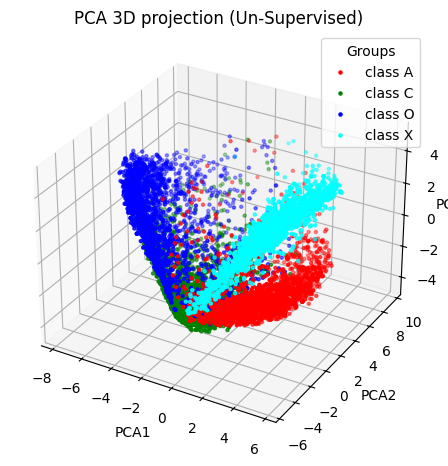

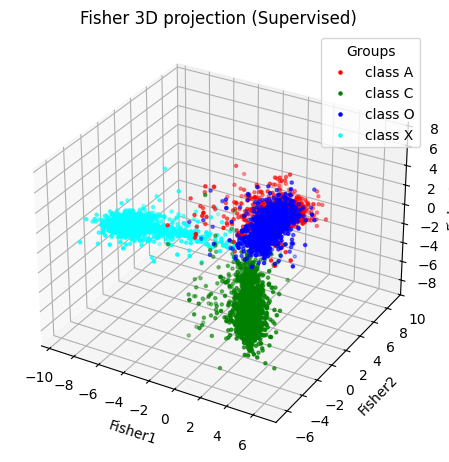

In [77]:
# Calling the function with default classes
lst=['A' ,'C','O','X']
pca_vs_fisher_3d(train_df,lst)


#### Output Summary : Comapring both the projection for Fishers' and PCA it that be easily concluded Fishers's LDA leads to better seperation of the classes 

#### First rep of the executing pca_vs_fisher_3d model with ['D' ,'R','L','Z'] parameters

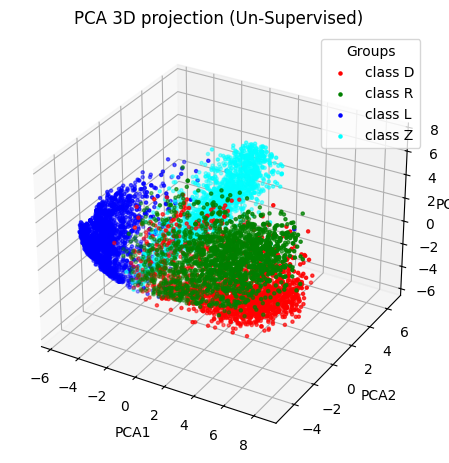

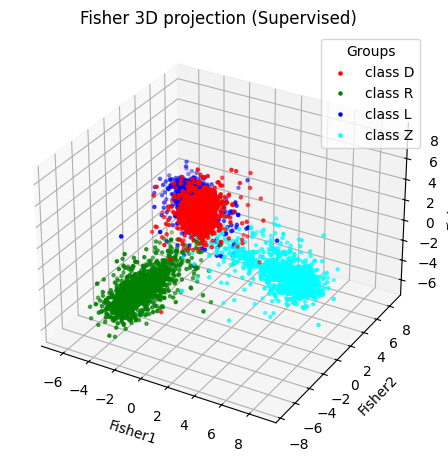

In [78]:
pca_vs_fisher_3d(train_df, ['D' ,'R','L','Z'])

#### Second rep of the executing pca_vs_fisher_3d model with ['B','K','Q','R'] parameters

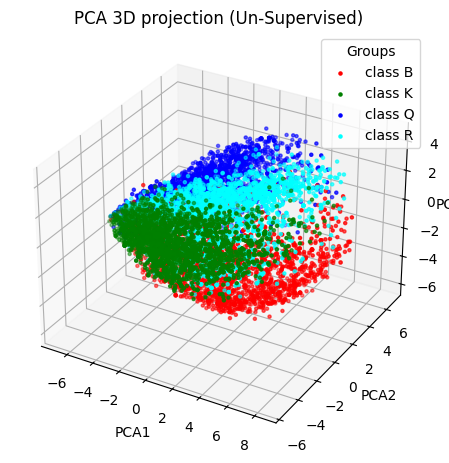

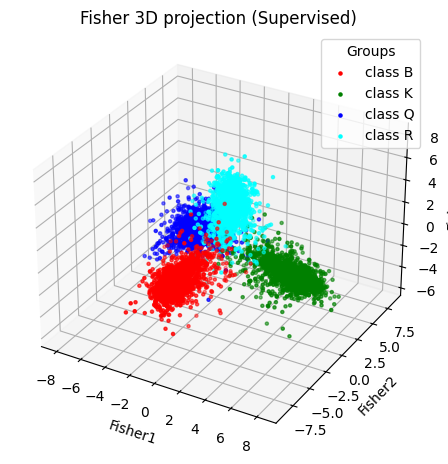

In [79]:

pca_vs_fisher_3d(train_df, ['B','K','Q','R'])

#### Third rep of the executing pca_vs_fisher_3d model with ['E','M','Q','S'] parameters

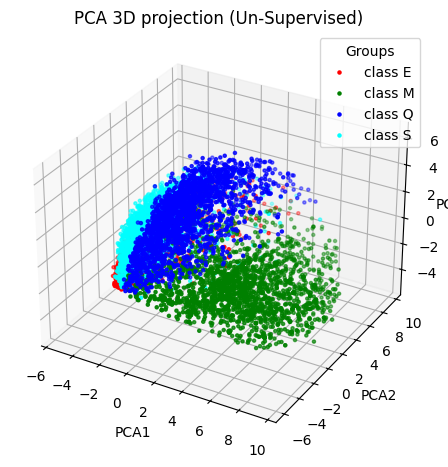

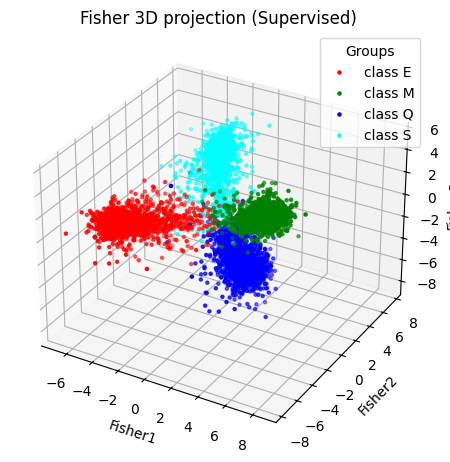

In [80]:
pca_vs_fisher_3d(train_df, ['E','M','Q','S'])

## Output Summary : 
#### Comapring both the projection for Fishers' and PCA it that be easily concluded Fishers's LDA leads to better seperation of the classes 

### Problem 2 

### Visualizing all Classes via their Fisher Distance

#### This task analyzes the distinctness of 26 letter classes (A-Z) by measuring how easily distinguishable every pair of letters is.
----
### Part 1 (Pairwise Fisher Scores): we need to calculate a "separability score" (Fisher Discriminant) for every unique pair of letters (e.g., 'A' vs 'B', 'A' vs 'C'...). High scores indicate the letters are easy to distinguish; low scores indicate they look similar. 

### Part 2 (2D Map of Similarity): we need to convert these pairwise scores into a visual map (using MDS - Multi-Dimensional Scaling). In this map, letters that are confusingly similar (low Fisher score) should appear close together, while distinct letters (high Fisher score) should be far apart.
---

#### Part 1: FISHER DISTANCE COMPUTATION

#### Step 1 Define the Alphabet pairs to calculate Fisher's score

In [81]:
## create pairs of the 26 alphabets
alphabets = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
## create pairs of the 26 alphabets
from itertools import combinations
alphabets_pairs =list(combinations(alphabets, 2))


#### Step 2 Define function to calculate Fisher score 
#### Since there are N=2 classes, the maximum number of discriminant components is $N-1 = 1$.

In [82]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
#from sklearn.metrics import accuracy_score
def calculate_Fisher_Discriminant_Score(train_df,pair):
  lda = LDA(n_components=1)
  lda.fit(train_df.drop('labels',axis=1),train_df['labels'])
  fisher_scores = lda.transform(train_df.drop('labels',axis=1)).flatten()
  # Split projected data back into two groups
  proj_a = fisher_scores[train_df['labels'] == pair[0]]
  proj_b = fisher_scores[train_df['labels'] == pair[1]]
    
    # Calculate Fisher Ratio J
  mean_diff = (np.mean(proj_a) - np.mean(proj_b))**2
  total_var = np.var(proj_a) + np.var(proj_b)
  # Avoid division by zero
  if total_var == 0: return 0.0
    
  return mean_diff / total_var
  #return fisher_scores


In [83]:
#initialize list to store fisher scores
fisher_scores=[]

### Step 3 Iterate through the pair of alphabets

In [84]:
#Iterate through the pair of alphabets
for pair in alphabets_pairs:
    pairs_scores={'Class1':'','Class2':'','fisher Discriminant scores':0.0}
    pair_df = train_df[train_df['labels'].isin(pair)]
    pairs_scores['Class1']=pair[0]
    pairs_scores['Class2']=pair[1]
    pairs_scores['fisher Discriminant scores']=calculate_Fisher_Discriminant_Score(pair_df,pair)
    #append to fisher_scores list
    fisher_scores.append(pairs_scores)  

    

In [85]:
df_fisher_scores=pd.DataFrame(fisher_scores)
df_fisher_scores.sort_values(by='fisher Discriminant scores', ascending=True).head(10)

,Class1,Class2,fisher Discriminant scores
172,I,J,13.960059
260,O,Q,14.594914
142,G,O,15.190390
82,D,O,15.644803
144,G,Q,16.416678
52,C,G,17.859645
242,M,V,19.046707
264,O,U,20.881220
310,U,V,21.012809
60,C,O,21.306527


In [86]:
## save as csv
df_fisher_scores.to_csv('Fisher_Matrix.csv')

#### Interpret the Fisher's Matrix: based on the output it can be seen (I,J) (O,Q) have the smallest Fisher's Score which make sense as they both have almost same structure and Aplphabets like (L,T) and (D,X) have the largest Fisher's Score being very dissimilar 

  ### Part 2: CLASS VISUALIZATION USING t-SNE/MDS

#### Step 4 Before creating a 2-D plot using Multi dimensional Scaling (MDS) we need to create a N*N matrix, in this case 26*26 

In [87]:
## Create fisher's matrix
fisher_matrix = np.zeros((26, 26))
for index, row in df_fisher_scores.iterrows():
    class1 = row['Class1']
    class2 = row['Class2']
    score = row['fisher Discriminant scores']
    # Convert class letters to indices (A=0, B=1, ..., Z=25)
    idx1 = ord(class1) - ord('A')
    idx2 = ord(class2) - ord('A')
    fisher_matrix[idx1, idx2] = score
    fisher_matrix[idx2, idx1] = score  # Symmetric matrix

### Created a heat map for the Fisher'score matrix of the 26 alpabets ,it will help us visualize the distance between any given alphabet

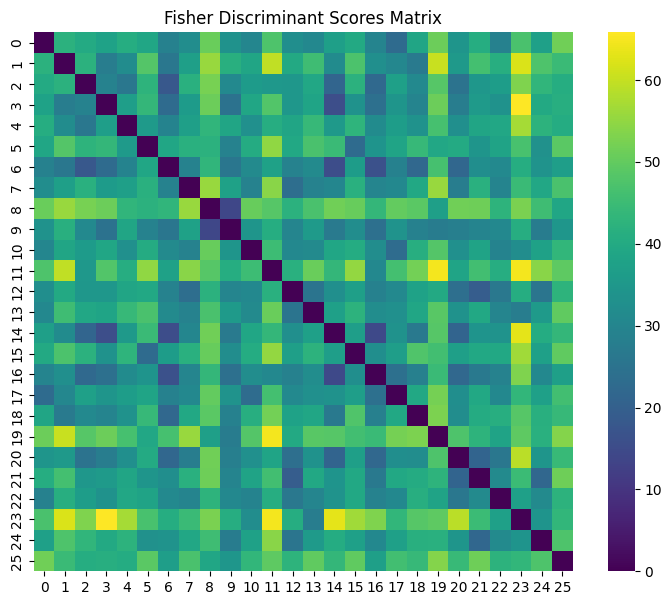

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))
sns.heatmap(fisher_matrix, cmap="viridis", square=True)
plt.title("Fisher Discriminant Scores Matrix")
plt.show()

#### Step 5 creating MDS project of the 26*26 Fisher's matrix this will reduce the points to a 2-D corrdinates 

In [89]:
from sklearn.manifold import MDS
print("Running MDS projection...")
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, normalized_stress='auto',n_init=4)
coords = mds.fit_transform(fisher_matrix)


Running MDS projection...


#### Step 6 Display the co-ordinates 

In [90]:
# Create a dataframe of MDS coordinates and corresponding labels
# coords is an (26,2) array and alphabets is a list of 26 letters
df_cord = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    
    'labels': alphabets
})

# display the dataframe
df_cord.head()


,x,y,labels
0,4.766065,27.209470,A
1,-18.979750,28.821750,B
2,-18.882291,-1.065606,C
3,-20.631708,10.701102,D
4,-22.084197,-8.925955,E


#### Step 7 Plot the 2-D projection of the 26 alphabets ,w.r.t there Fisher's score

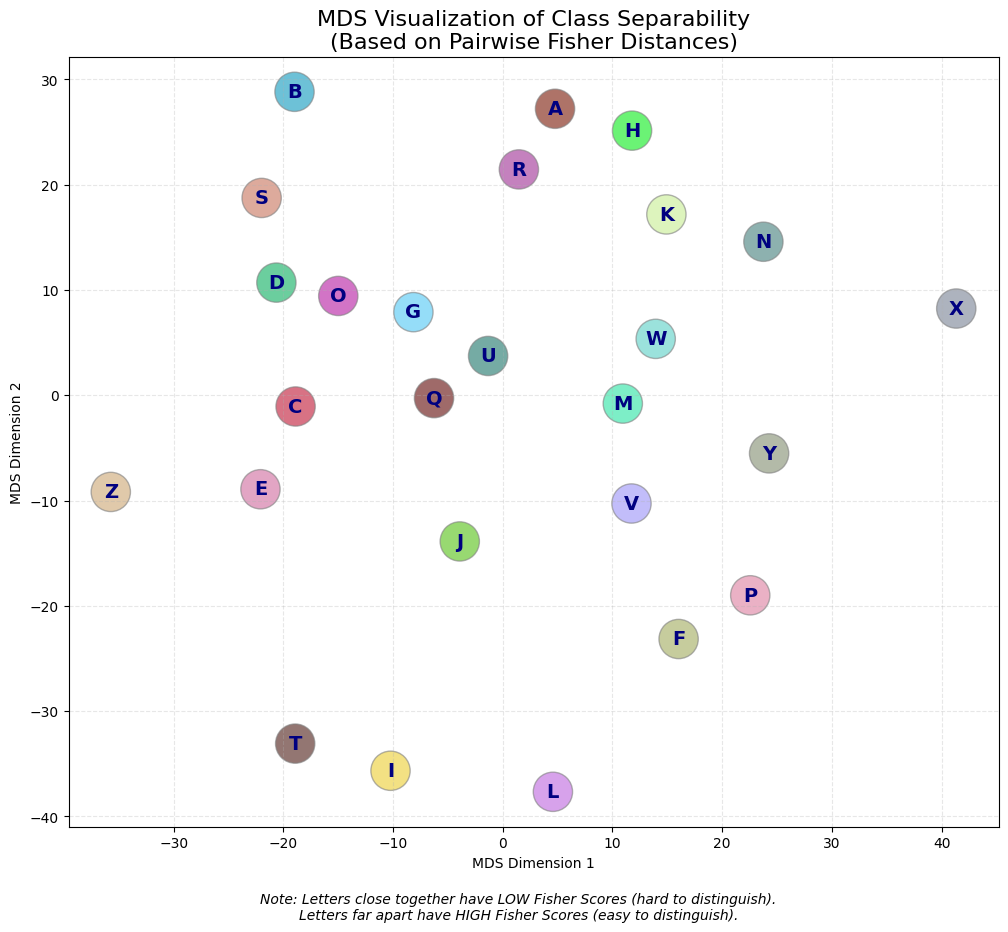

In [91]:
random_colors = np.random.rand(26, 3)
plt.figure(figsize=(12, 10))
plt.scatter(coords[:, 0], coords[:, 1], color=random_colors, s=800, alpha=0.6, edgecolors='gray')

# Annotate points with Letters
for i, txt in enumerate(alphabets):
    plt.text(coords[i, 0], coords[i, 1], txt, 
             fontsize=14, ha='center', va='center', fontweight='bold', color='navy')

plt.title("MDS Visualization of Class Separability\n(Based on Pairwise Fisher Distances)", fontsize=16)
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)

# Add an explanatory note on the plot
plt.figtext(0.5, 0.02, "Note: Letters close together have LOW Fisher Scores (hard to distinguish).\nLetters far apart have HIGH Fisher Scores (easy to distinguish).", 
            wrap=True, horizontalalignment='center', fontsize=10, style='italic')

plt.show()

In [92]:
df_fisher_scores.head(20)

,Class1,Class2,fisher Discriminant scores
0,A,B,41.939468
1,A,C,40.003823
2,A,D,38.009790
3,A,E,40.809558
4,A,F,39.085246
5,A,G,28.792593
6,A,H,32.054787
7,A,I,50.687804
8,A,J,33.546288
9,A,K,30.247046


### Outcome Summary :
---
#### Two classes with small Fisher distance are close to each other,Two classes with larger Fisher distance are far from each other
##### this is evident as per the above plot As A-R have a low Fisher's Discriminant Score of 22.7 ,and they both are very closely placed in  the plot ,

#### further $I,L,T$ have a very high Fisher's Discriminant Score and they are the farthest to A on the plot 
----



## Problem 3

##### The objective is to optimize and evaluate two non-parametric classifiers—K-Nearest Neighbors (KNN) and Parzen Window—on a dataset of 26 classes (likely alphabet letters).
----
##### $Dimensionality Reduction$: Before classification, compress the high-dimensional data (784 features) down to 25 dimensions using Fisher’s Linear Discriminant Analysis (LDA).
##### $KNN Sweep$: Test odd $k$ values from 1 to 17. Measure how training and testing accuracy changes as $k$ increases (model becomes simpler/smoother).
##### $Parzen Sweep$: Test Gaussian kernel bandwidths ($\sigma$) from 0.1 to 10. Measure how accuracy changes as the "window size" of the kernel changes.
----
##### Two plots visualizing the Trade-off between bias and variance (Train vs. Test accuracy curves).

#### KNN and Parzen Window classifiers hyper parameter sweeps

#### Step 1 Project the 26 class, 784 dimensional data into 25 Fisher-dimensions

In [93]:
## perform LDA on the entire training data and evaluate on test data
Lda_analysis = LDA(n_components=25)
train_lda=Lda_analysis.fit_transform(train_df.drop('labels', axis=1), train_df['labels'])
test_lda=Lda_analysis.transform(test_df.drop('labels', axis=1))
print(train_lda)


[[ 0.8376  0.057   2.229  ... -1.0296  0.815   0.7713]
 [ 9.0556 -0.7831 -2.0991 ... -0.777   0.5698  0.512 ]
 [-0.1364 -1.6856  0.3906 ... -0.1348 -1.0581 -0.4943]
 ...
 [-3.3763  2.7121  2.1454 ... -0.5275 -0.0452 -0.5982]
 [ 5.055  -0.693  -1.0387 ... -0.8541 -0.5821  0.3263]
 [ 0.0788  7.19    1.0931 ...  1.1741  0.482  -3.2312]]


In [94]:
#convert to dataframes
df_train_lda=pd.DataFrame(train_lda)
df_test_lda=pd.DataFrame(test_lda)
df_train_lda['labels']=train_df['labels'].values
df_test_lda['labels']=test_df['labels'].values
df_test_lda.head()


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,labels
0,-2.692297,1.963892,1.767069,0.675176,2.222784,1.585818,-0.551585,-3.863819,2.493981,1.752685,...,1.226042,0.034419,2.141616,-1.611681,-1.158755,0.892198,0.287236,1.926259,-1.289104,X
1,-2.518682,-2.430573,-1.731620,-3.859445,0.253971,-0.795761,-3.816625,-1.841761,0.396706,1.990841,...,2.300966,1.812797,0.271470,0.918973,3.493099,-0.999706,1.028618,1.320403,0.761981,C
2,-0.674885,-2.024416,1.712820,-2.768872,0.758772,-2.095142,-0.470391,0.236078,-2.338753,-0.595111,...,-0.167462,-0.603648,0.659361,1.273423,-0.742906,1.027921,-0.252945,-0.224081,1.056697,U
3,1.370166,3.312280,-5.430535,-2.125902,-4.674570,-3.882577,0.338431,3.402577,0.867487,0.357039,...,0.386358,-0.363800,0.859158,0.812869,-0.258149,-0.391787,0.272045,1.167159,2.599920,Z
4,-1.824110,2.788935,-6.933349,0.860341,9.545322,-1.044871,1.373625,1.623864,-0.996322,-0.131372,...,-1.790904,-0.592715,0.733449,-1.729526,0.339428,-0.469599,1.290201,1.345049,0.134798,L


#### Step 2 defines function knn_sweep that performs a hyperparameter sweep to find the optimal number of neighbors ($K$) for a K-Nearest Neighbors (KNN) classifier

In [95]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
def knn_sweep(train, test, K = [1, 3, 5, 7, 9, 11, 13, 15, 17]):
    for k in K:
        df_prediction={'K_value':0,'train_accuracy':0.0,'test_accuracy':0.0}
        knn=KNeighborsClassifier(n_neighbors=k)
        knn_col=knn.fit(train.drop('labels', axis=1), train['labels'])
        df_prediction['K_value']=k
        train_predictions=knn_col.predict(train.drop('labels', axis=1))
        
        df_prediction['train_accuracy']=accuracy_score(train['labels'],train_predictions)
        #predict on test data
        test_predictions=knn_col.predict(test.drop('labels', axis=1))
        df_prediction['test_accuracy']=accuracy_score(test['labels'], test_predictions)
        df_knn_results.append(df_prediction)
    

In [96]:
df_knn_results=[]
knn_sweep(df_train_lda, df_test_lda)
df_knn_results_df=pd.DataFrame(df_knn_results)
df_knn_results_df.head()

,K_value,train_accuracy,test_accuracy
0,1,1.000000,0.947587
1,3,0.969296,0.944018
2,5,0.961075,0.943081
3,7,0.956544,0.940762
4,9,0.953619,0.939691


### Step 3: Generate CSV file to plot train_accuracy and test_accuracy against a K_value


In [97]:
df_knn_results_df.to_csv('Knn.csv')

### Step 4: create plot for the Train accuracy vs Test accuracy for a given K-value

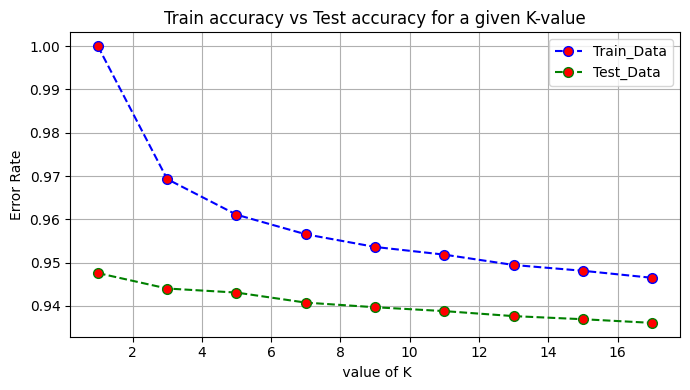

In [98]:
from matplotlib import pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(df_knn_results_df['K_value'], df_knn_results_df['train_accuracy'],color='blue',linestyle='dashed',marker='o', markerfacecolor='red', markersize='7',label="Train_Data")
plt.plot(df_knn_results_df['K_value'], df_knn_results_df['test_accuracy'],color='green',linestyle='dashed',marker='o', markerfacecolor='red', markersize='7',label="Test_Data")
plt.title("Train accuracy vs Test accuracy for a given K-value")
plt.xlabel(' value of K')
plt.ylabel('Error Rate')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

## Outcome Summary:
#### LDA : It is crucial to fit the LDA only on the Train data and then apply that transformation (transform) to the Test data.
#### As the K -value increases the model becomes simpler/smoother and error rate reduces for both test and train

### Part 2 Parzen window

### Step 1 As Parzen window is class is not available ,need to define a class ParzenWindowClassifier that help us perform function to use Parzen window as a model
##### code implements the Parzen Window Density Estimation (also known as Kernel Density Estimation) using a Gaussian Kernel.
----
##### The Loop (Summing the Kernels):The core idea of Parzen Windows is that every training point $x_i$ contributes a small "Gaussian hill" of probability to the space. We sum these up to get the total density.
##### Normalization (The Return Statement): Finally, the sum is normalized so that the total area under the density curve equals 1.
-----

In [99]:
class ParzenWindowClassifier:
    
    # h is like how much you “spread” your attention when comparing items.
    # Smaller h → you only look at very close points
    #Larger h → you look more broadly
    #Think of h as how sharp or blurry your vision is when checking similarity.
    
    def __init__(self, h=1.0):
        self.h = h

    # This step is like:
    # X = features (what each fruit looks like)
    # y = labels (apple, orange, banana)
    # It simply stores the data so the model can use it later.
    
    def fit(self, X, y):
        self.X = X
        self.y = y
        self.classes = np.unique(y)

    # This function asks:
    # How close is the new point (x) to all known examples of one class?
    # It does this by:
    # Looping through every example of the class
    #### It compares the new fruit to each fruit in the class
    #### Calculates a similarity score
    #### Adds them up and Returns a final “density score”
    
    def parzen_density(self, x, X_class):
        d = X_class.shape[1]
        n = X_class.shape[0]
        kernel_values = 0
        for xi in X_class:
            diff = x - xi
            exponent = -0.5 * np.dot(diff, diff) / (self.h ** 2)
            kernel_values += np.exp(exponent)
        return (1 / (n * (2 * np.pi * (self.h ** 2)) ** (d / 2))) * kernel_values


    # This part takes new items and figures out which class they belong to.
    # For each new item:
    # It checks how similar the item is to:
    # apples
    # oranges
    # bananas
    # (or whatever the classes are)
    # Picks the class with the highest score
    # It collects similarity scores:
    
    def predict(self, X_test):
        y_pred = []
        for x in X_test:
            probs = []
            for c in self.classes:
                X_c = self.X[self.y == c]
                p_x_c = self.parzen_density(x, X_c)
                probs.append(p_x_c)
            y_pred.append(self.classes[np.argmax(probs)])
        return np.array(y_pred)

### Step 2: As parzen window is resource consuming ,we only take 10% of the data to reduce the execution time

In [104]:
# Sample 1% of the data, maintaining the ratio of 'labels'
# NOTE: pandas.DataFrame.groupby does not accept `include_groups`; remove it.
sampled_train_lda_df, sampled_test_lda_df = train_test_split(
    df_train_lda, test_size=0.99, stratify=df_train_lda["labels"], random_state=42
)
sampled_train_lda_df

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,labels
24329,-1.211309,-0.799160,-0.451552,0.585614,-1.972789,0.680728,1.039907,2.670393,0.343368,-1.551821,...,-0.424248,-0.795248,1.306754,-0.698284,-0.628987,0.481997,-0.541321,0.248973,-0.026181,B
31411,-1.340169,4.698646,0.726270,-2.183449,0.411439,-0.259871,-1.940706,-1.683207,2.128225,-2.193818,...,0.832400,0.523983,0.805982,-1.114422,-2.686361,-0.894831,3.339023,-0.350872,1.707268,K
35065,-0.972532,1.084449,1.959040,0.100885,0.278062,0.053737,-0.042938,1.126425,1.513728,-1.735257,...,0.094009,0.502403,-0.089550,2.364257,-0.057684,0.274637,0.818732,-0.270728,-1.675258,H
1960,-0.152862,-0.349071,0.092215,-0.066645,0.349415,-0.459608,-0.092510,-0.522276,-0.116164,0.041225,...,0.288366,0.305382,0.077274,0.228982,0.082844,-0.395397,-0.103149,-0.631828,-0.344561,Q
19231,10.241814,-0.749221,-1.956168,-2.485761,-1.541428,0.643275,-0.580322,-2.170121,-1.161779,-2.229590,...,-1.790551,0.208321,-1.801517,-1.626063,1.862221,-1.591245,-1.701925,-0.976586,-0.433115,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40256,-1.958327,-2.913187,-0.048226,-0.151394,-0.699925,-1.041285,0.474897,-0.666421,-1.291074,0.557477,...,0.679164,-0.555600,0.083181,0.405069,0.678277,0.799848,0.961428,1.789685,0.021518,O
33973,0.866904,1.008299,3.136110,0.667257,2.514655,-2.708524,2.697033,-0.780990,2.525754,-0.001482,...,1.929814,0.036267,-3.118151,-1.145231,0.691539,-0.350656,-1.597367,-0.527761,1.305677,M
12996,0.750828,2.335827,-4.331223,-0.504223,-3.837731,-3.431921,2.165195,3.802055,-0.089044,-0.478424,...,0.629765,-1.861650,0.645192,0.469371,1.594693,1.923730,-1.049679,0.373994,0.140861,Z
9601,-0.561066,2.209642,0.655483,-0.067868,0.111462,-0.434210,-1.401348,-2.359754,-2.898326,-6.087575,...,0.602354,0.366535,0.361499,-0.644742,-0.537530,-0.088329,1.137568,-0.615101,0.124279,W


### Step 3: defines function ParzenWindowClassifier that performs a hyperparameter sweep to find the optimal number of sigma value

In [105]:
from sklearn.metrics import accuracy_score
def parzen_sweep(train, test, sigma = [1, 3, 5, 7, 9, 11, 13, 15, 17]):
    for s in sigma:
        model = ParzenWindowClassifier(h=s)
        # pass only numeric features (no label column) to the classifier
        df_prediction={'sigma_value':0,'train_accuracy':0.0,'test_accuracy':0.0}
        X_train = train.drop('labels', axis=1).values
        y_train = train['labels'].values
        model.fit(X_train, y_train)

        X_test = test.drop('labels', axis=1).values
        pred = model.predict(X_test)
        
        # Predict on training data
        train_pred = model.predict(X_train)

        # Calculate accuracy
        df_prediction['sigma_value']=s
        df_prediction['train_accuracy'] = accuracy_score(y_train, train_pred)
        df_prediction['test_accuracy']= accuracy_score(test['labels'].values, pred)
        parzen_results.append(df_prediction)
      

### step 4: Call the Model function for prediction

In [106]:
parzen_results=[]    
parzen_sweep(sampled_train_lda_df, df_test_lda)
df_parzen_results=pd.DataFrame(parzen_results)
print(df_parzen_results)

   sigma_value  train_accuracy  test_accuracy
0            1        1.000000       0.873450
1            3        0.959847       0.880632
2            5        0.917782       0.875457
3            7        0.902486       0.871799
4            9        0.900574       0.869926
5           11        0.900574       0.868855
6           13        0.900574       0.867785
7           15        0.900574       0.867562
8           17        0.902486       0.867250


### Step 5: Generate CSV file to plot train_accuracy and test_accuracy against a sigma value

In [107]:
#create a csv for parzen results
df_parzen_results.to_csv('Parzen.csv')

### Step 6: create plot for the Train accuracy vs Test accuracy for any given sigma-value

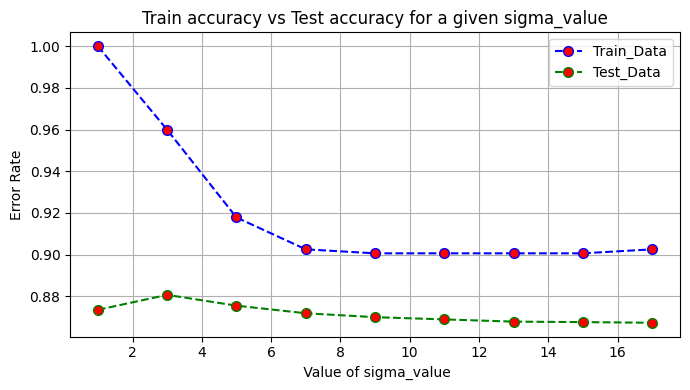

In [108]:
from matplotlib import pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(df_parzen_results['sigma_value'], df_parzen_results['train_accuracy'],color='blue',linestyle='dashed',marker='o', markerfacecolor='red', markersize='7',label="Train_Data")
plt.plot(df_parzen_results['sigma_value'], df_parzen_results['test_accuracy'],color='green',linestyle='dashed',marker='o', markerfacecolor='red', markersize='7',label="Test_Data")
plt.title("Train accuracy vs Test accuracy for a given sigma_value")
plt.xlabel(' Value of sigma_value')
plt.ylabel('Error Rate')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

### Outcome Summary :The Parzen Window classifier is computationally expensive because it compares every test point against every training point. Running the sweep on very large datasets takes time,hence have taken only 10% of data,with increase in sigma value the error rate significantly reduces

## PROBLEM 4: Perceptron vs. Logistic Regression

#### The goal is to compare the stability and performance of two linear classifiers—Perceptron and Logistic Regression—on a binary classification task (e.g., distinguishing 'A' from 'C').
----
##### Data Context: This step uses the 25-dimensional Fisher projected data (computed in the previous step) rather than the raw pixels.
##### Robustness Check: Since optimization algorithms can depend on their starting point (initial weights), you must train 100 separate models for each algorithm, using a different random initialization each time.
---
#### Comparison:

Histograms: Visualize the spread of accuracy scores. (Is the model stable or does it vary wildly?)

Averages: Compute the mean performance.

Output: Save detailed logs to CSV files.

In [109]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

## Perceptrons 

### Step 1: define function to create perceptron model with 100 different seeds
#### Perceptron models can yield different results based on their starting random weights, this function trains the model 100 times (using 100 different random seeds) to see how stable the accuracy i

In [110]:
from sklearn.linear_model import Perceptron

def perceptron_model(train,test, classes = ['A', 'C']):
    names='_'.join(classes)
    file_name='perceptron_'+names+'.csv'
    for seed in range(100):
        le = LabelEncoder()

        train_df = train[train['labels'].isin(classes)].copy()
        test_df = test[test['labels'].isin(classes)].copy()
        #y_train_int = le.fit_transform(train_df['labels'])
        #y_test_int = le.transform(test_df['labels'])
        
        model = Perceptron(random_state=seed, max_iter=1000, eta0=1.0,fit_intercept=True)
        df_perceptron={'run':[],'train_accuracy':0.0,'test_accuracy':0.0}      
        
        model.fit(train_df.drop('labels', axis=1),train_df['labels'])
        y_p_train = model.predict(train_df.drop('labels',axis=1))
        y_p_test = model.predict(test_df.drop('labels',axis=1))
        df_perceptron['run']=seed +1
        df_perceptron['train_accuracy']=accuracy_score(train_df['labels'], y_p_train)
        df_perceptron['test_accuracy']=accuracy_score(test_df['labels'], y_p_test)
        perceptron_results.append(df_perceptron)
    return file_name

#### Step 2: Call the perceptron model 

In [111]:
perceptron_results=[]
file_name=perceptron_model(df_train_lda,df_test_lda)
df_perceptron_results=pd.DataFrame(perceptron_results)
df_perceptron_results.to_csv(file_name,index=False)
df_perceptron_results.head()

,run,train_accuracy,test_accuracy
0,1,0.997266,0.993039
1,2,0.994533,0.990139
2,3,0.995775,0.992459
3,4,0.994781,0.989559
4,5,0.995527,0.990139


#### Step 3 Plot Histogram  (train and test accuracy  ) 

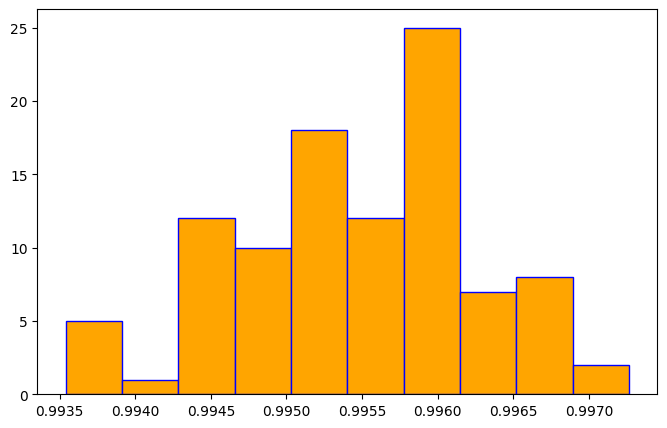

In [112]:
plt.figure(figsize=(8,5))
plt.hist(x=df_perceptron_results['train_accuracy'],color='orange',edgecolor='blue')
plt.title='Perceptron-Train Accuracy plot'
plt.xlabel='Perceptron Accuracy'
plt.ylabel='Frequency'
plt.show()


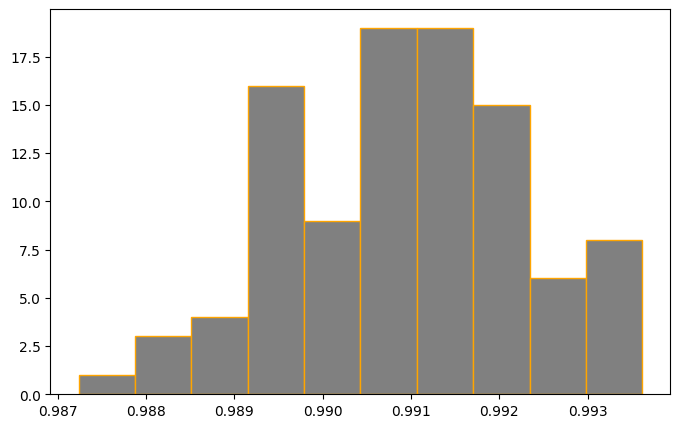

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(x=df_perceptron_results['test_accuracy'],color='grey',edgecolor='orange')
plt.title='Perceptron-Test Accuracy plot'
plt.xlabel='Perceptron Accuracy'
plt.ylabel='Frequency'
plt.show()

### Outcome Summary :
##### The Perceptron algorithm suggest a wider spread range in the Perceptron histograms (higher variance) because different random starts lead to different final weights.

### Part 2 Logistic Regresssion 

### Step 1:Code for defining Logistic Regression classifier
#### this code checks how stable the Logistic Regression model is when trained on slightly different subsets of data
$(Note)$ Inside every loop, only 95% of the train data is considered to increase the randomness

In [114]:
from sklearn.linear_model import LogisticRegression
def logistic_model(train, test, classes = ['A', 'C']):
     df_train = train[train['labels'].isin(classes)].copy()
     df_test = test[test['labels'].isin(classes)].copy()
     names='_'.join(classes)
     file_name2='logistic_'+names+'.csv'
     for seed in range(100):
        X_train=[]
        X_train,x_test= train_test_split(
            df_train, test_size=0.05, random_state=seed,stratify=df_train['labels']
        )
        df = pd.DataFrame(X_train)
        
              
        model=LogisticRegression(random_state=seed, max_iter=1000, solver='lbfgs')
        df_logreg={'run':[],'train_accuracy':0.0,'test_accuracy':0.0}
        
        model.fit(df.drop('labels',axis=1),df['labels'] )
        y_p_train = model.predict(df.drop('labels',axis=1))
        y_p_test = model.predict(df_test.drop('labels',axis=1))
        df_logreg['run']=seed+1
        df_logreg['train_accuracy']=accuracy_score(df['labels'], y_p_train)
        df_logreg['test_accuracy']=accuracy_score(df_test['labels'], y_p_test)
        logreg_results.append(df_logreg)
     return file_name2


### Step 2:Call the Logistic Regression model 

In [115]:
logreg_results=[]
file_name=logistic_model(df_train_lda, df_test_lda,['A','C'])
df_logreg_results=pd.DataFrame(logreg_results)

df_logreg_results.to_csv(file_name,index=False)
df_logreg_results.head(15)

,run,train_accuracy,test_accuracy
0,1,0.997122,0.991299
1,2,0.996860,0.990719
2,3,0.996860,0.991299
3,4,0.997384,0.993039
4,5,0.997122,0.990719
5,6,0.996337,0.992459
6,7,0.996860,0.991879
7,8,0.996860,0.992459
8,9,0.997122,0.991879
9,10,0.996337,0.991879


#### Step 3 Plot Histogram  (train and test accuracy  ) 

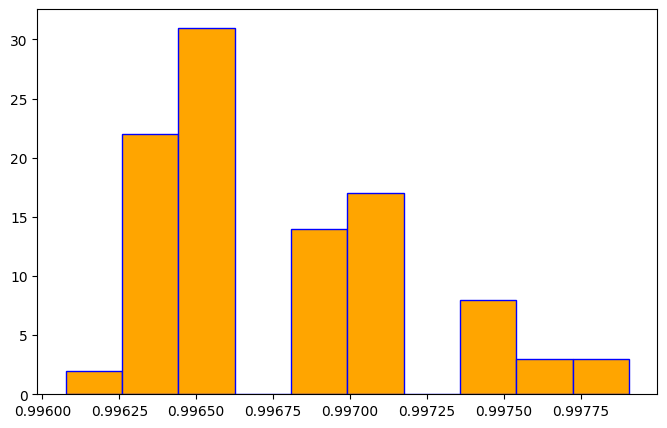

In [116]:
plt.figure(figsize=(8,5))
plt.hist(x=df_logreg_results['train_accuracy'],color='orange',edgecolor='blue')
plt.title='Logistic-Train Accuracy plot'
plt.xlabel='Logistic Accuracy'
plt.ylabel='Frequency'
plt.show()


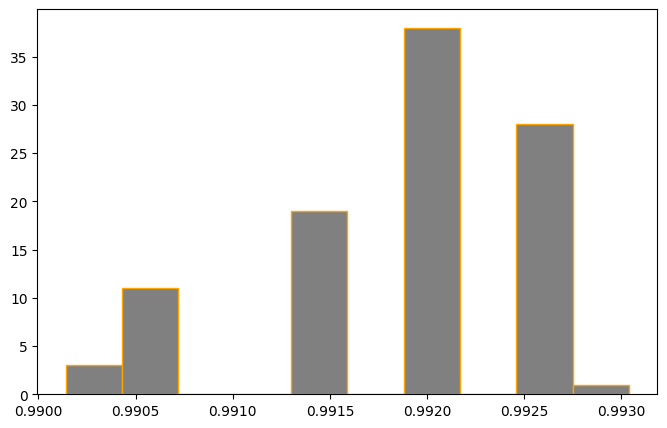

In [117]:
plt.figure(figsize=(8,5))
plt.hist(x=df_logreg_results['test_accuracy'],color='grey',edgecolor='orange')
plt.title='Logistic-Test Accuracy plot'
plt.xlabel='Logistic Accuracy'
plt.ylabel='Frequency'
plt.show()


## Outcome Summary :

#### Logistic Regression minimizes a continuous loss function. Logistic Regression histograms is spikier (narrower) in range, indicating that almost every random run resulted in the same accuracy,even when we introduced additional randomness as compared to perceptron by taking only 95% of test data at a time